# Demixed population geometry

## tl;dr

For GRB006 session 20240821_121447, the first three dPCs capture 36.9% of condition-mean variance in condition-independent activity, 3.3% in stimulus-category activity, 10.9% in response activity, and 2.2% in category-by-response interactions. The leading response component separates left and right choices mainly after center exit.

Gabriel's fork of the MATLAB port and the original Python package recover the same unregularized solution when the original package's randomized SVD is given enough refinement iterations.

**Validation status:** executed successfully from top to bottom against the lab database.

## Context & Methods

The analysis uses the [Machens lab dPCA package](https://github.com/machenslab/dPCA), which implements the method from [Kobak et al. (2016)](https://doi.org/10.7554/eLife.10989). It fits a balanced tensor with dimensions `unit × category × response × phase`.

### Key assumptions

- Units pass quality criterion 1 and stability parameter 0. No stimulus-response filter is applied.
- Trials have a left or right response, no early withdrawal, and ordered hardware timestamps for first stimulus, center exit, and response-port entry.
- Low-rate, boundary, and high-rate trials are balanced across left and right responses.
- Each trial is normalized into 25 stimulus-to-center-exit bins and 10 center-exit-to-response bins. The phase axis does not preserve real-time speed.
- Unit scaling is estimated from balanced single-trial activity before condition averaging.
- Category and category-by-phase terms are joined as the stimulus marginalization. Response and response-by-phase terms are joined as the response marginalization. Remaining interactions are joined together.
- Exact stimulus rate is not included because category is derived from rate. A separate rate-by-response analysis would require enough trials in each exact-rate group.
- This first pass is unregularized and is fit to condition means. The original Python package uses seven randomized-SVD refinement iterations instead of its zero-iteration default. It is descriptive and is not yet validated on held-out trials. Component plots overlay raw scores with display-only Gaussian smoothing of one phase bin, applied separately to the two task phases.

## Setup

Load packages and define the analysis parameters.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dPCA import dPCA
from IPython.display import display
from matlab_dpca import dpca as fit_matlab_dpca
from matlab_dpca import explained_variance as matlab_explained_variance
from matplotlib.lines import Line2D
from scipy.linalg import subspace_angles
from scipy.ndimage import gaussian_filter1d

from thesis.ephys.trials import build_trial_table
from thesis.ephys.units import fetch_unit_table

warnings.filterwarnings("ignore", category=UserWarning, module="datajoint.plugin")


SUBJECT = "GRB006"
SESSION = "20240821_121447"
UNIT_CRITERIA_ID = 1
STABILITY_PARAM_ID = 0

BASELINE_BINWIDTH_S = 0.020
PRE_STIM_S = 0.100
N_STIM_TO_EXIT_BINS = 25
N_EXIT_TO_RESPONSE_BINS = 10
N_COMPONENTS = 3
SVD_ITERATIONS = 7
SMOOTHING_SIGMA_BINS = 1.0
RANDOM_SEED = 0

CATEGORIES = ("low_rate", "boundary", "high_rate")
RESPONSES = (-1, 1)
CATEGORY_COLORS = {
    "low_rate": "#6A3D9A",
    "boundary": "0.45",
    "high_rate": "#E6AB02",
}
RESPONSE_LINESTYLES = {-1: "-", 1: "--"}

## Data

Load synchronized trials and units that pass the selected quality and stability filters.

In [2]:
trial_table = build_trial_table(SUBJECT, SESSION).copy()
unit_table = fetch_unit_table(
    SUBJECT,
    SESSION,
    unit_criteria_id=UNIT_CRITERIA_ID,
    stability_param_id=STABILITY_PARAM_ID,
)

trial_table["first_stim_s"] = trial_table["stim_pulse_times_s"].str[0]
required_times = ["first_stim_s", "center_exit_s", "response_port_entry_s"]
finite_times = np.isfinite(trial_table[required_times].to_numpy(dtype=float)).all(
    axis=1
)
ordered_events = trial_table["first_stim_s"].lt(
    trial_table["center_exit_s"]
) & trial_table["center_exit_s"].lt(trial_table["response_port_entry_s"])
valid_trials = (
    trial_table["response"].isin(RESPONSES)
    & trial_table["early_withdrawal"].fillna(1).eq(0)
    & trial_table["stim_category"].notna()
    & finite_times
    & ordered_events
)
eligible_trials = trial_table.loc[valid_trials].reset_index(drop=True)

if eligible_trials.empty:
    raise RuntimeError("No trials pass the dPCA inclusion rules.")

print(f"Session: {SUBJECT} {SESSION}")
print(f"Units: {len(unit_table)}")
print(f"Eligible trials: {len(eligible_trials)} / {len(trial_table)}")
display(
    eligible_trials.groupby(["stim_category", "response"], observed=True)
    .size()
    .rename("trials")
    .unstack(fill_value=0)
)

[2026-08-26 13:50:46,634][INFO]: DataJoint 0.14.8 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


Session: GRB006 20240821_121447
Units: 168
Eligible trials: 294 / 504


response,-1,1
stim_category,,
low_rate,105,25
boundary,36,17
high_rate,64,47


Balance category-by-response groups so common trial types do not dominate the condition means.

In [3]:
def sample_balanced_indices(trials, rng):
    groups = [
        group.index.to_numpy(dtype=int)
        for _, group in trials.groupby(
            ["stim_category", "response"], observed=True, sort=True
        )
    ]
    if len(groups) != 6:
        raise RuntimeError(
            "Expected low, boundary, and high categories with both responses."
        )
    n_per_group = min(map(len, groups))
    if n_per_group < 2:
        raise RuntimeError(
            f"The least represented category-by-response group has {n_per_group} trial(s)."
        )
    return np.sort(
        np.concatenate(
            [rng.choice(group, n_per_group, replace=False) for group in groups]
        )
    )


balanced_trial_indices = sample_balanced_indices(
    eligible_trials, np.random.default_rng(RANDOM_SEED)
)
balanced_trials = eligible_trials.iloc[balanced_trial_indices]

print(f"Balanced trials: {len(balanced_trials)}")
display(
    balanced_trials.groupby(["stim_category", "response"], observed=True)
    .size()
    .rename("trials")
    .unstack(fill_value=0)
)

Balanced trials: 102


response,-1,1
stim_category,,
low_rate,17,17
boundary,17,17
high_rate,17,17


Convert spikes into unsmoothed firing rates for the two normalized task phases and the pre-stimulus baseline.

In [4]:
spike_times_by_unit = [
    np.sort(np.asarray(spike_times, dtype=float))
    for spike_times in unit_table["spike_times_s"]
]
n_pre_stim_bins = round(PRE_STIM_S / BASELINE_BINWIDTH_S)


def firing_rates_in_bins(edges_s):
    bin_durations_s = np.diff(edges_s)
    return np.column_stack(
        [
            np.diff(np.searchsorted(spike_times_s, edges_s)) / bin_durations_s
            for spike_times_s in spike_times_by_unit
        ]
    )


def phase_rates(trial):
    stim_to_exit_edges = np.linspace(
        trial["first_stim_s"],
        trial["center_exit_s"],
        N_STIM_TO_EXIT_BINS + 1,
    )
    exit_to_response_edges = np.linspace(
        trial["center_exit_s"],
        trial["response_port_entry_s"],
        N_EXIT_TO_RESPONSE_BINS + 1,
    )
    return np.vstack(
        [
            firing_rates_in_bins(stim_to_exit_edges),
            firing_rates_in_bins(exit_to_response_edges),
        ]
    )


phase_activity = np.stack(
    [phase_rates(trial) for _, trial in eligible_trials.iterrows()]
)
baseline_activity = np.stack(
    [
        firing_rates_in_bins(
            np.linspace(
                trial["first_stim_s"] - PRE_STIM_S,
                trial["first_stim_s"],
                n_pre_stim_bins + 1,
            )
        )
        for _, trial in eligible_trials.iterrows()
    ]
)

print("Phase activity:", phase_activity.shape, "(trials, phase bins, units)")
print("Baseline activity:", baseline_activity.shape)

Phase activity: (294, 35, 168) (trials, phase bins, units)
Baseline activity: (294, 5, 168)


Build the balanced `unit × category × response × phase` tensor used by dPCA.

In [5]:
baseline_rate = baseline_activity[balanced_trial_indices].mean(axis=(0, 1))
reference_activity = phase_activity[balanced_trial_indices] - baseline_rate
unit_scale = reference_activity.reshape(-1, phase_activity.shape[-1]).std(
    axis=0, ddof=1
)
included_units = np.isfinite(unit_scale) & (unit_scale > 0)
standardized_activity = (
    phase_activity[..., included_units] - baseline_rate[included_units]
) / unit_scale[included_units]

condition_activity = np.empty(
    (
        included_units.sum(),
        len(CATEGORIES),
        len(RESPONSES),
        N_STIM_TO_EXIT_BINS + N_EXIT_TO_RESPONSE_BINS,
    )
)
for category_index, category in enumerate(CATEGORIES):
    for response_index, response in enumerate(RESPONSES):
        condition_trials = balanced_trials.index[
            balanced_trials["stim_category"].astype(str).eq(category)
            & balanced_trials["response"].eq(response)
        ].to_numpy(dtype=int)
        condition_activity[:, category_index, response_index] = (
            standardized_activity[condition_trials].mean(axis=0).T
        )

print(
    f"Units retained after variance check: {included_units.sum()} / {len(unit_table)}"
)
print("dPCA tensor:", condition_activity.shape, "(units, category, response, phase)")

Units retained after variance check: 168 / 168
dPCA tensor: (168, 3, 2, 35) (units, category, response, phase)


## Results

Fit unregularized dPCA with the official package. Trial phase, category, response, and interaction terms are joined into four marginalizations.

In [6]:
marginalization_terms = {
    "time": ["t"],
    "category": ["c", "ct"],
    "response": ["r", "rt"],
    "interaction": ["cr", "crt"],
}
marginalization_names = {
    "time": "Condition-independent",
    "category": "Stimulus category",
    "response": "Response",
    "interaction": "Interaction",
}

# The official package draws the randomized SVD seed from NumPy's global RNG.
np.random.seed(RANDOM_SEED)
model = dPCA.dPCA(
    labels="crt",
    join=marginalization_terms,
    n_components=N_COMPONENTS,
    regularizer=None,
    n_iter=SVD_ITERATIONS,
)
package_scores = model.fit_transform(condition_activity)
component_scores = {
    marginalization_names[name]: scores for name, scores in package_scores.items()
}
component_variance = {
    marginalization_names[name]: 100 * np.asarray(explained)
    for name, explained in model.explained_variance_ratio_.items()
}

variance_table = pd.DataFrame(
    {
        "dpc1_variance_pct": {
            name: explained[0] for name, explained in component_variance.items()
        },
        "dpc1_to_3_variance_pct": {
            name: explained.sum() for name, explained in component_variance.items()
        },
    }
)
display(variance_table.round(2))

,dpc1_variance_pct,dpc1_to_3_variance_pct
Condition-independent,28.47,36.94
Stimulus category,1.86,3.33
Response,7.27,10.90
Interaction,0.89,2.22


Compare the percentage of total condition-mean variance captured by the first three dPCs in each marginalization.

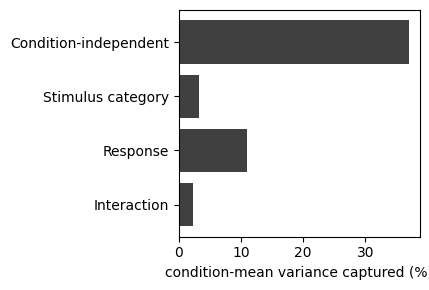

In [7]:
fig, ax = plt.subplots(figsize=(4.4, 3.0))
positions = np.arange(len(variance_table))
ax.barh(
    positions,
    variance_table["dpc1_to_3_variance_pct"],
    color="0.25",
)
ax.set(
    yticks=positions,
    yticklabels=variance_table.index,
    xlabel="condition-mean variance captured (%)",
)
ax.invert_yaxis()
fig.tight_layout()

Plot the leading component for each marginalization across the full normalized trial. Faint lines show raw scores and strong lines show display-smoothed scores. Color identifies stimulus category; line style identifies response.

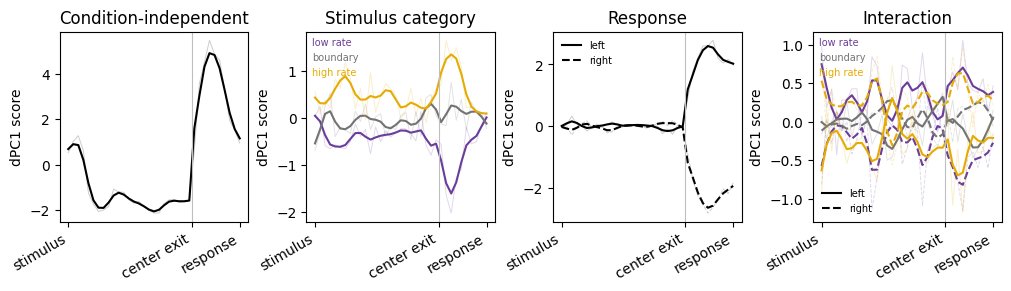

In [8]:
def add_category_key(ax):
    for row, category in enumerate(CATEGORIES):
        ax.text(
            0.03,
            0.97 - 0.08 * row,
            category.replace("_", " "),
            color=CATEGORY_COLORS[category],
            fontsize=7,
            transform=ax.transAxes,
            va="top",
        )


def smooth_phase(scores):
    return np.concatenate(
        [
            gaussian_filter1d(
                scores[..., :N_STIM_TO_EXIT_BINS],
                SMOOTHING_SIGMA_BINS,
                axis=-1,
                mode="nearest",
            ),
            gaussian_filter1d(
                scores[..., N_STIM_TO_EXIT_BINS:],
                SMOOTHING_SIGMA_BINS,
                axis=-1,
                mode="nearest",
            ),
        ],
        axis=-1,
    )


def plot_component(ax, scores, *, color, linestyle="-"):
    ax.plot(
        phase_bins,
        scores,
        color=color,
        linestyle=linestyle,
        linewidth=0.7,
        alpha=0.2,
    )
    ax.plot(
        phase_bins,
        smooth_phase(scores),
        color=color,
        linestyle=linestyle,
        linewidth=1.5,
    )


phase_bins = np.arange(N_STIM_TO_EXIT_BINS + N_EXIT_TO_RESPONSE_BINS)
response_handles = [
    Line2D([], [], color="black", linestyle=RESPONSE_LINESTYLES[-1], label="left"),
    Line2D([], [], color="black", linestyle=RESPONSE_LINESTYLES[1], label="right"),
]

fig, axes = plt.subplots(1, 4, figsize=(10.0, 2.8), layout="constrained")
for ax, (name, scores) in zip(axes, component_scores.items(), strict=True):
    if name == "Condition-independent":
        plot_component(ax, scores[0].mean(axis=(0, 1)), color="black")
    elif name == "Stimulus category":
        for category_index, category in enumerate(CATEGORIES):
            plot_component(
                ax,
                scores[0, category_index].mean(axis=0),
                color=CATEGORY_COLORS[category],
            )
        add_category_key(ax)
    elif name == "Response":
        for response_index, response in enumerate(RESPONSES):
            plot_component(
                ax,
                scores[0, :, response_index].mean(axis=0),
                color="black",
                linestyle=RESPONSE_LINESTYLES[response],
            )
        ax.legend(handles=response_handles, frameon=False, fontsize=7)
    else:
        for category_index, category in enumerate(CATEGORIES):
            for response_index, response in enumerate(RESPONSES):
                plot_component(
                    ax,
                    scores[0, category_index, response_index],
                    color=CATEGORY_COLORS[category],
                    linestyle=RESPONSE_LINESTYLES[response],
                )
        add_category_key(ax)
        ax.legend(handles=response_handles, frameon=False, fontsize=7, loc="lower left")

    ax.axvline(N_STIM_TO_EXIT_BINS - 0.5, color="0.75", linewidth=0.8)
    ax.set_title(name)
    ax.set_xticks(
        [0, N_STIM_TO_EXIT_BINS - 0.5, len(phase_bins) - 1],
        ["stimulus", "center exit", "response"],
        rotation=30,
        ha="right",
    )
    ax.set_ylabel("dPC1 score")

fig.align_ylabels(axes)

### Implementation comparison

Fit Gabriel's fork of the MATLAB-to-Python port to the same condition tensor. Compare variance capture and basis-independent reconstruction similarity with the original Python package.

In [9]:
matlab_combined_params = [
    [[1], [1, 3]],
    [[2], [2, 3]],
    [[3]],
    [[1, 2], [1, 2, 3]],
]
matlab_marginalization_index = {
    "category": 0,
    "response": 1,
    "time": 2,
    "interaction": 3,
}

matlab_decoder, matlab_encoder, matlab_component_marginalization = fit_matlab_dpca(
    condition_activity,
    [N_COMPONENTS] * len(matlab_combined_params),
    combined_params=matlab_combined_params,
    lambda_=0.0,
)
matlab_variance = matlab_explained_variance(
    condition_activity,
    matlab_decoder,
    matlab_encoder,
    combined_params=matlab_combined_params,
)

centered_flat_activity = condition_activity.reshape(condition_activity.shape[0], -1)
centered_flat_activity -= centered_flat_activity.mean(axis=1, keepdims=True)

comparison_rows = []
for package_name, display_name in marginalization_names.items():
    matlab_index = matlab_marginalization_index[package_name]
    matlab_components = np.flatnonzero(matlab_component_marginalization == matlab_index)
    package_reconstruction = model.P[package_name] @ (
        model.D[package_name].T @ centered_flat_activity
    )
    matlab_reconstruction = matlab_encoder[:, matlab_components] @ (
        matlab_decoder[:, matlab_components].T @ centered_flat_activity
    )

    comparison_rows.append(
        {
            "marginalization": display_name,
            "original_python_variance_pct": component_variance[display_name].sum(),
            "matlab_port_variance_pct": matlab_variance.marg_var[
                matlab_index, matlab_components
            ].sum(),
            "reconstruction_r": np.corrcoef(
                package_reconstruction.ravel(),
                matlab_reconstruction.ravel(),
            )[0, 1],
            "largest_decoder_angle_deg": np.degrees(
                subspace_angles(
                    model.D[package_name],
                    matlab_decoder[:, matlab_components],
                )
            ).max(),
        }
    )

implementation_comparison = pd.DataFrame(comparison_rows).set_index("marginalization")
display(implementation_comparison.round(3))

,original_python_variance_pct,matlab_port_variance_pct,reconstruction_r,largest_decoder_angle_deg
marginalization,,,,
Condition-independent,36.935,36.935,1.0,0.000
Stimulus category,3.334,3.334,1.0,0.379
Response,10.904,10.904,1.0,0.001
Interaction,2.223,2.223,1.0,2.940


## Takeaways

- The first three dPCs capture 36.9% of total condition-mean variance from condition-independent activity, 3.3% from category activity, 10.9% from response activity, and 2.2% from interaction activity.
- The leading response component shows the clearest demixing and separates left and right choices mainly after center exit.
- The leading category component separates low- and high-rate categories most strongly late in the trial. The interaction component remains irregular.
- The original Python package and Gabriel's MATLAB-port fork produce identical variance estimates and reconstruction correlations of 1.000. Their largest three-component decoder-subspace difference is 2.94°.
- The original package's zero-iteration randomized-SVD default underestimates the smaller category and interaction components. Seven refinement iterations remove that discrepancy.

This first pass is descriptive. The axes and variance estimates are fit and evaluated on the same condition means. Add trial-level regularization and held-out validation before using dPCA for a scientific claim.